# Proyecto Extra-Clase #2 - Kevin Amador Fallas


---


# Dataset **" 202509-capitalbikeshare-tripdata "**

**Fuente:** https://capitalbikeshare.com/system-data

## *Capital Bikeshare* (Washington D.C.)

El dataset proviene del sistema de bicicletas compartidas **Capital Bikeshare**, un **servicio público** de movilidad urbana que opera en Washington D.C. Este sistema cuenta con miles de bicicletas distribuidas en docenas de estaciones automáticas, permitiendo a residentes y visitantes desplazarse de forma **rápida**, **sostenible** y **económica** dentro del área metropolitana.

Estos datos permiten estudiar **patrones** de transporte, **comportamiento** de los usuarios, **estacionalidad**, **congestión** en estaciones, **eficiencia** del sistema y **tendencias** generales de movilidad.

Contiene datos de tiempo:

* Fecha y hora de inicio y finalización

* Estación donde inicia y termina el viaje

* Duración del trayecto

## Comprensión y Preparación de Datos

### Carga y exploración inicial.

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
df_RAW = pd.read_csv("/content/ds_proyecto2_Kevin.csv")

In [73]:
# INFORMACIÓN BÁSICA DEL DATASET
print(f"Dimensiones: {df_RAW.shape[0]} filas x {df_RAW.shape[1]} columnas")


Dimensiones: 625035 filas x 13 columnas


In [74]:
# COLUMNAS DEL DATASET
print(f"Columnas: \n{list(df_RAW.columns)}")


Columnas: 
['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual']


In [75]:
# VARIABLES DEL DATASET
variables_info = {
  'ride_id':'id_de_viaje',
  'rideable_type':'tipo_de_viaje',
  'started_at':'inicio_en',
  'ended_at':'finalización_en',
  'start_station_name':'nombre_de_estación_de_inicio',
  'start_station_id':'id_de_estación_de_inicio',
  'end_station_name':'nombre_de_estación_de_fin',
  'end_station_id':'id_de_estación_de_fin',
  'start_lat':'lat_de_inicio',
  'start_lng':'long_de_inicio',
  'end_lat':'lat_final',
  'end_lng':'long_final',
  'member_casual': 'tipo_de_usuario'
}


In [76]:
# TIPO DE DATOS
print("\n=== TIPO DE DATOS ===\n")
print(df_RAW.dtypes)
print("\n=== CANTIDAD DE CADA TIPO DE DATOS ===\n")
print(df_RAW.dtypes.value_counts())



=== TIPO DE DATOS ===

ride_id                object
rideable_type          object
started_at             object
ended_at               object
start_station_name     object
start_station_id      float64
end_station_name       object
end_station_id        float64
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual          object
dtype: object

=== CANTIDAD DE CADA TIPO DE DATOS ===

object     7
float64    6
Name: count, dtype: int64


In [77]:
# INFORMACIÓN GENERAL DEL DATASET
print("\n=== INFORMACIÓN GENERAL ===\n")
print(df_RAW.info())



=== INFORMACIÓN GENERAL ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625035 entries, 0 to 625034
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ride_id             625035 non-null  object 
 1   rideable_type       625035 non-null  object 
 2   started_at          625035 non-null  object 
 3   ended_at            625035 non-null  object 
 4   start_station_name  539752 non-null  object 
 5   start_station_id    539752 non-null  float64
 6   end_station_name    535926 non-null  object 
 7   end_station_id      535744 non-null  float64
 8   start_lat           625035 non-null  float64
 9   start_lng           625035 non-null  float64
 10  end_lat             624643 non-null  float64
 11  end_lng             624643 non-null  float64
 12  member_casual       625035 non-null  object 
dtypes: float64(6), object(7)
memory usage: 62.0+ MB
None


In [78]:
# PRIMERAS 5 FILAS DEL DATASET
print("\n=== PRIMERAS 5 FILAS DE INFORMACIÓN DEL DATASET ===\n")
df_RAW.head()



=== PRIMERAS 5 FILAS DE INFORMACIÓN DEL DATASET ===



,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,36E1F6684EF85CED,classic_bike,2025-09-30 12:20:37.380,2025-09-30 13:17:55.465,Anacostia Park,31820.0,Anacostia Park,31820.0,38.873308,-76.983363,38.873308,-76.983363,casual
1,C2EBB06C9D854B50,classic_bike,2025-09-27 13:12:55.611,2025-09-27 14:34:37.527,Woodmont Ave & Strathmore St,32055.0,Woodmont Ave & Strathmore St,32055.0,38.979875,-77.093522,38.979875,-77.093522,casual
2,DF3179E94BCA1B2C,electric_bike,2025-09-03 17:19:29.707,2025-09-03 17:38:06.217,Woodmont Ave & Strathmore St,32055.0,Woodmont Ave & Strathmore St,32055.0,38.979875,-77.093522,38.979875,-77.093522,casual
3,50DDBC6591F8F623,classic_bike,2025-09-05 13:50:26.253,2025-09-05 13:53:29.030,Mt Vernon Trail & S. Washington St.,31929.0,Mt Vernon Trail & S. Washington St.,31929.0,38.793065,-77.049436,38.793065,-77.049436,casual
4,4A073055A375B004,classic_bike,2025-09-05 13:50:10.110,2025-09-05 13:53:43.745,Mt Vernon Trail & S. Washington St.,31929.0,Mt Vernon Trail & S. Washington St.,31929.0,38.793065,-77.049436,38.793065,-77.049436,casual


In [79]:
# ÚLTIMAS 5 FILAS DEL DATASET
print("\n=== ÚLTIMAS 5 FILAS DE INFORMACIÓN DEL DATASET ===\n")
df_RAW.tail()



=== ÚLTIMAS 5 FILAS DE INFORMACIÓN DEL DATASET ===



,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
625030,D8A2D3DEB43AB42D,electric_bike,2025-09-15 18:44:02.375,2025-09-15 18:47:23.622,NaN,NaN,NaN,NaN,38.90,-77.06,38.91,-77.06,member
625031,C1C2F578972075AD,electric_bike,2025-09-20 17:50:44.733,2025-09-20 17:55:14.551,NaN,NaN,NaN,NaN,38.90,-77.06,38.90,-77.06,member
625032,C8FD14FB7C93E94B,electric_bike,2025-09-14 16:34:10.502,2025-09-14 16:34:17.205,NaN,NaN,NaN,NaN,38.89,-76.94,38.89,-76.94,member
625033,B5F7FFC60CE15CF7,electric_bike,2025-09-04 08:55:30.300,2025-09-04 08:57:29.796,NaN,NaN,NaN,NaN,38.90,-77.00,38.90,-77.00,member
625034,5C76614D78E8E0A3,electric_bike,2025-09-18 17:40:10.797,2025-09-18 18:04:37.367,NaN,NaN,NaN,NaN,38.96,-77.00,38.92,-77.02,member


### Evaluación de Calidad de Datos

In [80]:
# VALORES FALTANTES
missing_data = df_RAW.isnull().sum()
missing_percentage = (missing_data / len(df_RAW)) * 100
missing_df = pd.DataFrame({
    'Valores Faltantes': missing_data,
    'Porcentaje': missing_percentage
})
print("Columnas:", missing_df[missing_df['Valores Faltantes'] > 0])
if missing_df['Valores Faltantes'].sum() == 0:
    print("✅ No se encontraron valores faltantes en el dataset")
print()


Columnas:                     Valores Faltantes  Porcentaje
start_station_name              85283   13.644516
start_station_id                85283   13.644516
end_station_name                89109   14.256642
end_station_id                  89291   14.285760
end_lat                           392    0.062716
end_lng                           392    0.062716



In [81]:
# VALORES ÚNICOS
for col in df_RAW.columns:
    print(f"{col}: {df_RAW[col].nunique()} valores únicos")


ride_id: 625035 valores únicos
rideable_type: 2 valores únicos
started_at: 624912 valores únicos
ended_at: 624758 valores únicos
start_station_name: 818 valores únicos
start_station_id: 818 valores únicos
end_station_name: 819 valores únicos
end_station_id: 819 valores únicos
start_lat: 39338 valores únicos
start_lng: 39983 valores únicos
end_lat: 859 valores únicos
end_lng: 883 valores únicos
member_casual: 2 valores únicos


In [82]:
# DUPLICADOS
print("Duplicados totales:", df_RAW.duplicated().sum())


Duplicados totales: 0


In [83]:
# SEPARACIÓN DE COLUMNAS - NUMÉRICAS Y CATEGÓRICAS
numeric_cols = df_RAW.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_RAW.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numéricas:", numeric_cols)
print("Categóricas:", cat_cols)


Numéricas: ['start_station_id', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng']
Categóricas: ['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'end_station_name', 'member_casual']


#### Validación de consistencia de datos

In [84]:
issues = []

# 1. Conversión de fechas
df_RAW['started_at'] = pd.to_datetime(df_RAW['started_at'], errors='coerce')
df_RAW['ended_at']   = pd.to_datetime(df_RAW['ended_at'], errors='coerce')

if df_RAW['started_at'].isna().sum() > 0:
    issues.append(f"Fechas inválidas en 'started_at': {df_RAW['started_at'].isna().sum()} filas")

if df_RAW['ended_at'].isna().sum() > 0:
    issues.append(f"Fechas inválidas en 'ended_at': {df_RAW['ended_at'].isna().sum()} filas")


# 2. Duraciones imposibles
df_RAW['duration_sec'] = (df_RAW['ended_at'] - df_RAW['started_at']).dt.total_seconds()

negativos = df_RAW[df_RAW['duration_sec'] <= 0].shape[0]
largos = df_RAW[df_RAW['duration_sec'] > 86400].shape[0]

if negativos > 0:
    issues.append(f"Duraciones negativas o cero: {negativos} filas")

if largos > 0:
    issues.append(f"Duraciones mayores a 24h: {largos} filas")

# 3. Estaciones faltantes
faltantes_inicio = df_RAW['start_station_name'].isna().sum()
faltantes_fin = df_RAW['end_station_name'].isna().sum()

if faltantes_inicio > 0:
    issues.append(f"Nombres de estación de inicio faltantes: {faltantes_inicio} filas")

if faltantes_fin > 0:
    issues.append(f"Nombres de estación de destino faltantes: {faltantes_fin} filas")

# 4. Categorías inesperadas
# Columna member_casual debe tener solo 'member' y 'casual'
categorias_usuario = set(df_RAW['member_casual'].dropna().unique())
esperadas_usuario = {'member', 'casual'}

if not categorias_usuario.issubset(esperadas_usuario):
    issues.append(f"Categorías inesperadas en 'member_casual': {categorias_usuario - esperadas_usuario}")

# Rideable types usuales: classic_bike, electric_bike, docked_bike
categorias_bike = set(df_RAW['rideable_type'].dropna().unique())
esperadas_bike = {'classic_bike', 'electric_bike', 'docked_bike'}

if not categorias_bike.issubset(esperadas_bike):
    issues.append(f"Tipos de bicicleta inesperados en 'rideable_type': {categorias_bike - esperadas_bike}")

# 5. Coordenadas inválidas
coord_invalidas = df_RAW[
    (df_RAW['start_lat'].abs() > 90) |
    (df_RAW['start_lng'].abs() > 180) |
    (df_RAW['end_lat'].abs() > 90) |
    (df_RAW['end_lng'].abs() > 180)
].shape[0]

if coord_invalidas > 0:
    issues.append(f"Coordenadas fuera de rango válido: {coord_invalidas} filas")

# Resultado final
print("Chequeos rápidos:")
if issues:
    for it in issues:
        print("-", it)
else:
    print("No se detectaron problemas simples de consistencia.")


Chequeos rápidos:
- Duraciones mayores a 24h: 402 filas
- Nombres de estación de inicio faltantes: 85283 filas
- Nombres de estación de destino faltantes: 89109 filas


* Se identificaron **402 registros con duraciones mayores a 24 horas**, lo cual es inconsistente con el funcionamiento normal del sistema. Esto ocurre cuando una bicicleta no es acoplada correctamente o por errores de registro. Estos casos fueron eliminados debido a que representan outliers no representativos del comportamiento real de los usuarios.

* Se encontraron **85 283** registros con **estación de inicio** sin nombre y **89 109** registros con **estación de destino** sin nombre. Esto es común en sistemas de bikesharing, debido a viajes iniciados/terminados fuera de estaciones oficiales. Dado que dichos registros sí incluyen coordenadas geográficas válidas, no fueron eliminados; se sustituyó el valor faltante por la categoría “Unnamed Location” con el fin de conservar información relevante sin distorsionar el análisis.

### Limpieza y Transformación

In [85]:
# LIMPIEZA
# ELIMINAR VIAJES CON DURACIÓN > 24 HORAS
df_RAW = df_RAW[df_RAW['duration_sec'] <= 86400]

# IMPUTAR ESTACIONES FALTANTES
df_RAW['start_station_name'] = df_RAW['start_station_name'].fillna("Unknown Station")
df_RAW['end_station_name'] = df_RAW['end_station_name'].fillna("Unknown Station")


In [86]:
# TRANSFORMACIONES BÁSICAS
print("Transformaciones básicas...\n")

# 1. Tipos correctos
df_RAW['started_at'] = pd.to_datetime(df_RAW['started_at'])
df_RAW['ended_at'] = pd.to_datetime(df_RAW['ended_at'])
df_RAW['start_station_id'] = df_RAW['start_station_id'].astype(str)
df_RAW['end_station_id'] = df_RAW['end_station_id'].astype(str)
df_RAW['ride_id'] = df_RAW['ride_id'].astype(str)

print("Tipos de datos corregidos")

# 2. Crear variables de tiempo
df_RAW['start_hour'] = df_RAW['started_at'].dt.hour
df_RAW['start_day'] = df_RAW['started_at'].dt.day
df_RAW['start_weekday'] = df_RAW['started_at'].dt.day_name()
df_RAW['start_month'] = df_RAW['started_at'].dt.month
df_RAW['start_year'] = df_RAW['started_at'].dt.year
df_RAW['ride_length_min'] = df_RAW['duration_sec'] / 60  # minutos

print("Variables temporales creadas")


# 3. Estandarizar columnas categóricas
df_RAW['member_casual'] = df_RAW['member_casual'].str.lower().str.strip()
df_RAW['rideable_type'] = df_RAW['rideable_type'].str.lower().str.strip()
df_RAW['start_station_name'] = df_RAW['start_station_name'].str.strip()
df_RAW['end_station_name'] = df_RAW['end_station_name'].str.strip()

print("Categorías estandarizadas")

# 4. Crear variable de tipo de día (laboral / fin de semana)
df_RAW['is_weekend'] = df_RAW['start_weekday'].isin(['Saturday','Sunday']).astype(int)

print("Columna de fin de semana creada")

# 5. Clasificar duración en categorías
df_RAW['duration_category'] = pd.cut(
    df_RAW['ride_length_min'],
    bins=[0, 5, 15, 30, 60, float('inf')],
    labels=['Muy corto', 'Corto', 'Moderado', 'Largo', 'Muy largo'],
    right=False
)

print("Categorías de duración creadas")

# 6. Coordenadas a tipo float (por seguridad)
df_RAW['start_lat'] = df_RAW['start_lat'].astype(float)
df_RAW['start_lng'] = df_RAW['start_lng'].astype(float)
df_RAW['end_lat'] = df_RAW['end_lat'].astype(float)
df_RAW['end_lng'] = df_RAW['end_lng'].astype(float)

print("Coordenadas validadas")

# Resumen final
print("\nTransformaciones básicas aplicadas correctamente ✔️")
print("Nuevas columnas creadas:",
      ['start_hour', 'start_day', 'start_weekday',
       'start_month', 'start_year', 'ride_length_min',
       'is_weekend', 'duration_category'])


Transformaciones básicas...

Tipos de datos corregidos
Variables temporales creadas
Categorías estandarizadas
Columna de fin de semana creada
Categorías de duración creadas
Coordenadas validadas

Transformaciones básicas aplicadas correctamente ✔️
Nuevas columnas creadas: ['start_hour', 'start_day', 'start_weekday', 'start_month', 'start_year', 'ride_length_min', 'is_weekend', 'duration_category']


Se crearon esas variables derivadas para enriquecer el análisis, permiten analizar patrones temporales, diferencias entre usuarios y comportamientos generales con mayor claridad.

In [87]:
# Revisar valores faltantes después de toda la limpieza
missing_data = df_RAW.isnull().sum()
remaining_missing = missing_data[missing_data > 0]

print("Valores faltantes restantes:")
print(remaining_missing)

# Imputaciones finales
# imputar valores numéricos con la mediana
num_cols = df_RAW.select_dtypes(include=['float64','int64']).columns
df_RAW[num_cols] = df_RAW[num_cols].fillna(df_RAW[num_cols].median())

# imputar valores categóricos con la moda
cat_cols = df_RAW.select_dtypes(include=['object']).columns
df_RAW[cat_cols] = df_RAW[cat_cols].fillna(df_RAW[cat_cols].mode().iloc[0])

print("\nImputaciones finales aplicadas correctamente ✔️")


Valores faltantes restantes:
end_lat    8
end_lng    8
dtype: int64

Imputaciones finales aplicadas correctamente ✔️


### Crear versión limpia del dataset

In [88]:
#import os
#os.makedirs("data", exist_ok=True)

#df_RAW.to_csv("ds_proyecto2_Kevin_clean_v2.csv", index=False, encoding='utf-8')

#print("Dataset limpio guardado")


In [107]:
df = pd.read_csv("/content/ds_proyecto2_Kevin_clean_v2.csv")

## Análisis Univariado

### Variables Numéricas

In [108]:
# Estadísticas descriptivas
num_vars = df.select_dtypes(include=['float64','int64'])
num_stats = num_vars.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

num_stats


,start_station_id,end_station_id,start_lat,start_lng,end_lat,end_lng,duration_sec,start_hour,start_day,start_month,start_year,ride_length_min,is_weekend,log_duration_sec,log_ride_length_min
count,539350.000000,535732.000000,624633.000000,624633.000000,624633.000000,624633.000000,624633.000000,624633.000000,624633.000000,624633.000000,624633.0,624633.000000,624633.000000,624633.000000,624633.000000
mean,31406.185590,31407.324336,38.906663,-77.033219,38.906075,-77.033035,808.959985,14.187254,15.504360,8.999817,2025.0,13.482666,0.270820,6.295794,2.350340
std,329.636278,331.442662,0.028075,0.036905,0.028135,0.036909,1487.979962,4.981567,8.590367,0.013508,0.0,24.799666,0.444384,0.910657,0.748234
min,30200.000000,30200.000000,38.760000,-77.420000,38.710000,-77.420000,0.075000,0.000000,1.000000,8.000000,2025.0,0.001250,0.000000,0.072321,0.001249
1%,31005.000000,31005.000000,38.812718,-77.150000,38.811456,-77.150000,20.573000,0.000000,1.000000,9.000000,2025.0,0.342883,0.000000,3.071443,0.294819
5%,31056.000000,31060.000000,38.865553,-77.090000,38.865029,-77.089555,139.573600,6.000000,2.000000,9.000000,2025.0,2.326227,0.000000,4.945731,1.201839
25%,31209.000000,31212.000000,38.894573,-77.045640,38.894514,-77.045640,333.521000,10.000000,8.000000,9.000000,2025.0,5.558683,0.000000,5.812700,1.880790
50%,31298.000000,31297.000000,38.905691,-77.031500,38.905509,-77.030230,561.559000,15.000000,15.000000,9.000000,2025.0,9.359317,0.000000,6.332496,2.337886
75%,31616.000000,31618.000000,38.920000,-77.011987,38.918809,-77.011616,924.047000,18.000000,23.000000,9.000000,2025.0,15.400783,1.000000,6.829845,2.797329
95%,31982.000000,31982.000000,38.951419,-76.988355,38.950000,-76.988355,2094.241800,21.000000,29.000000,9.000000,2025.0,34.904030,1.000000,7.647424,3.580850


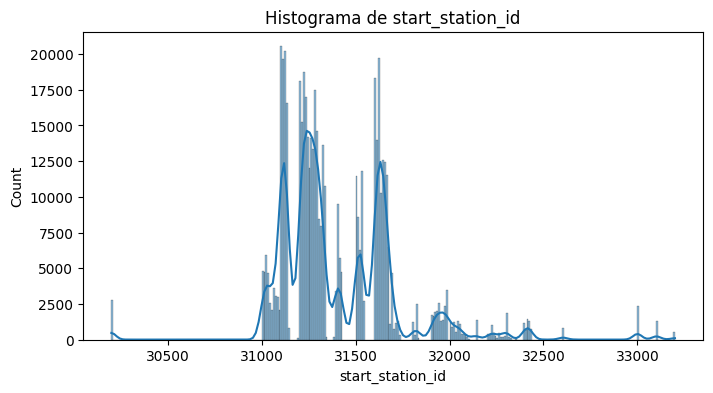

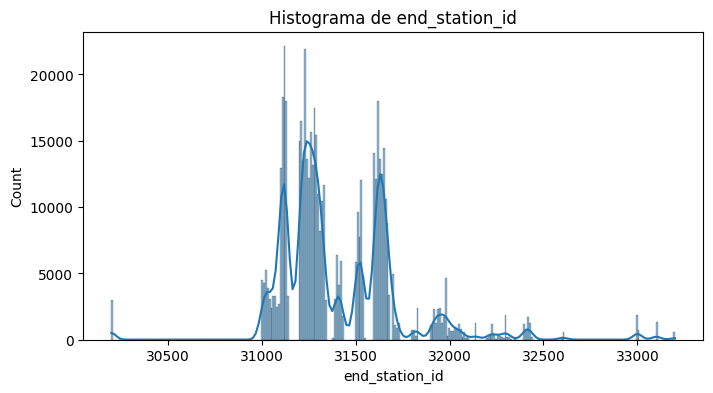

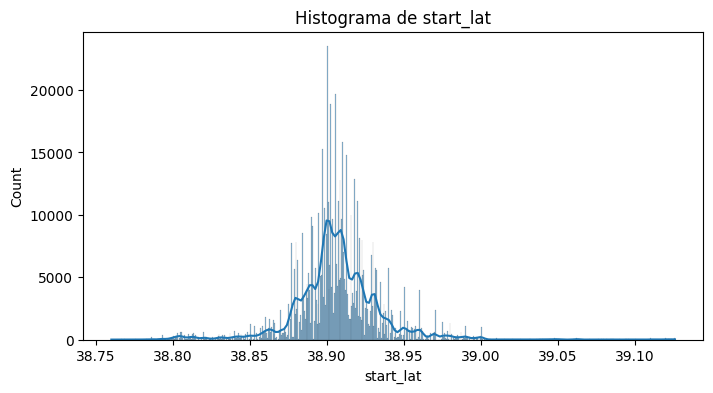

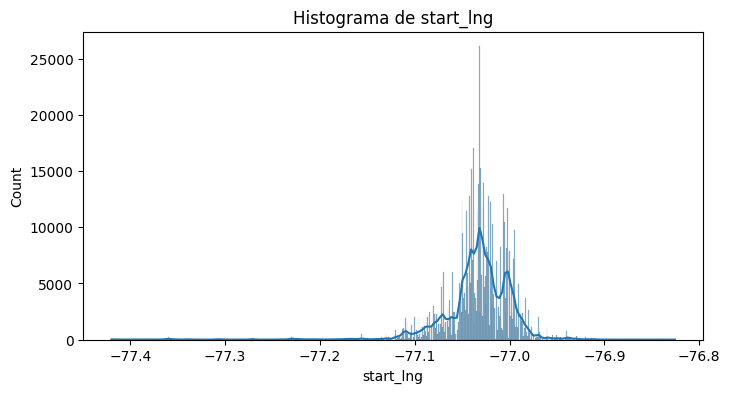

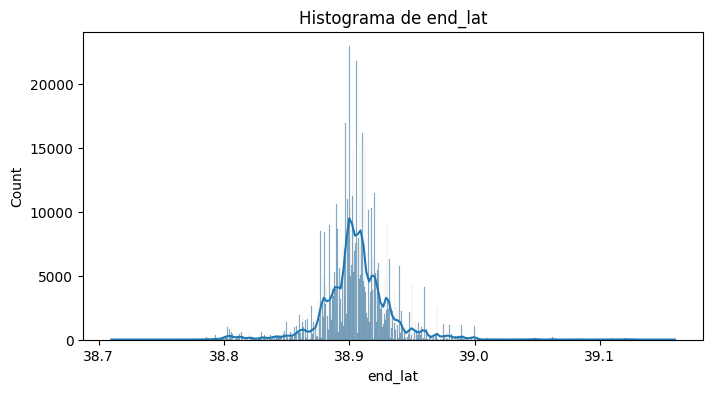

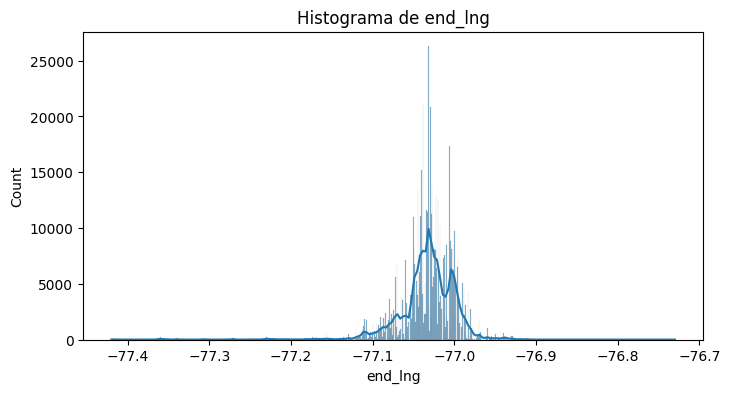

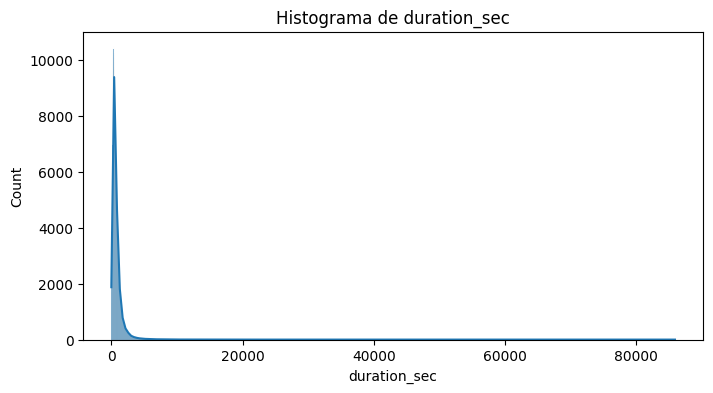

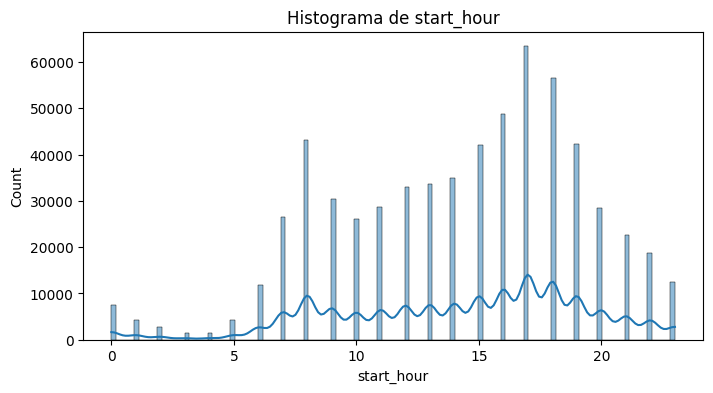

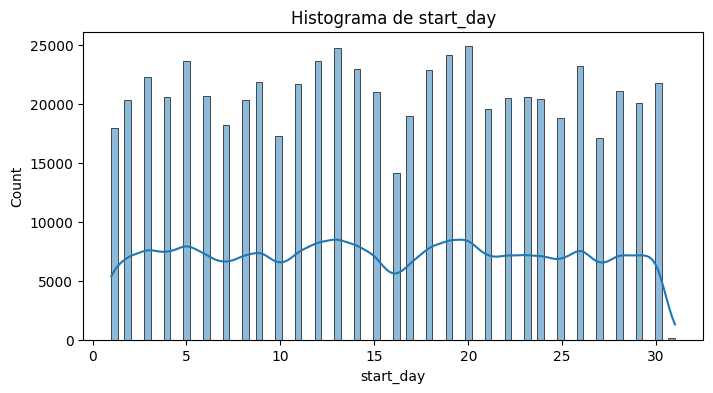

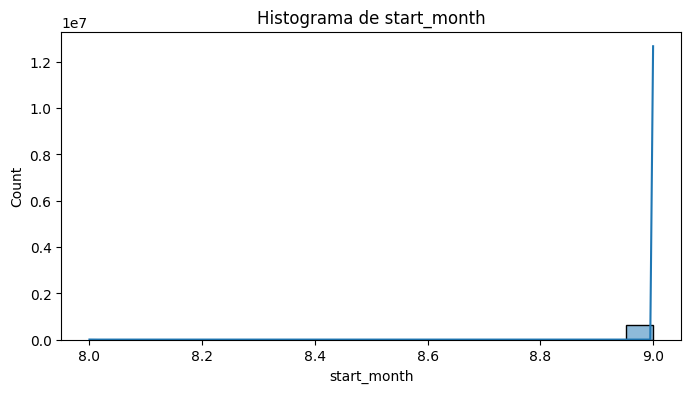

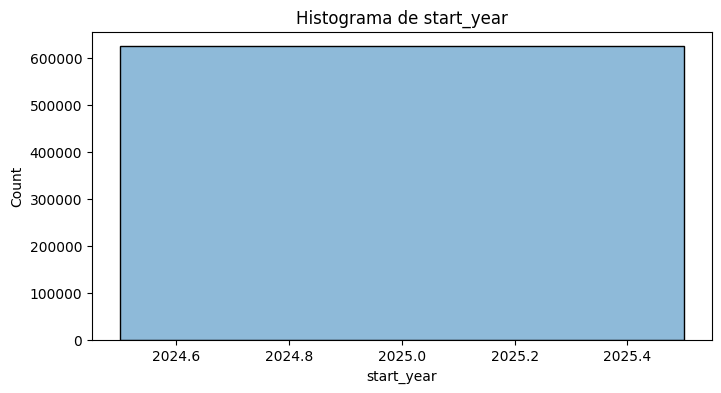

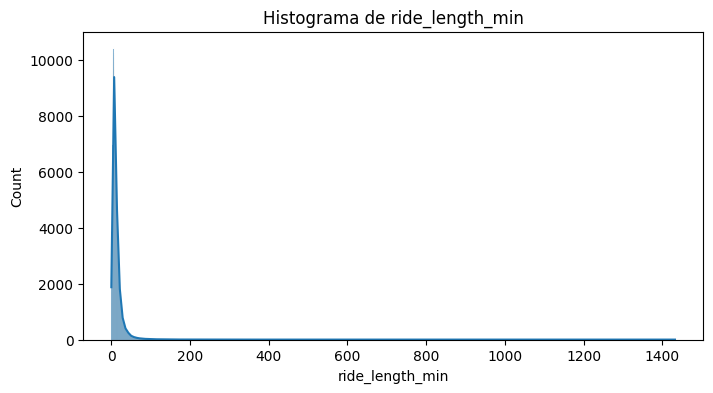

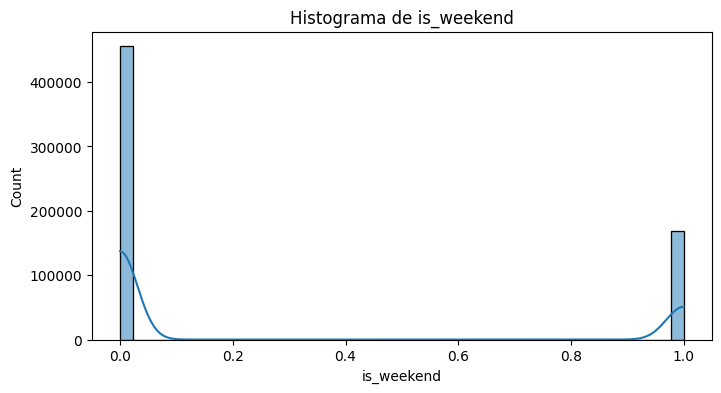

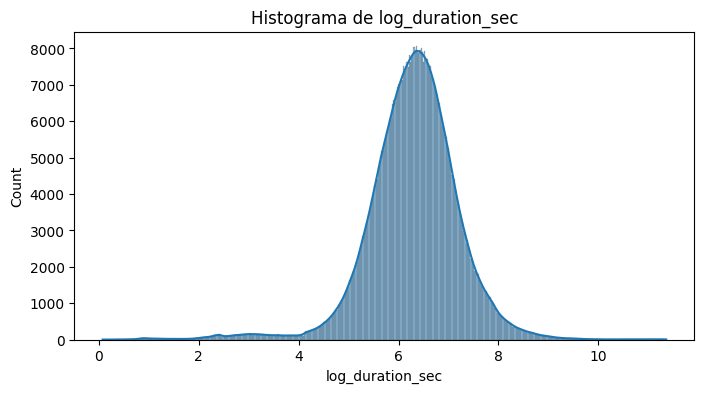

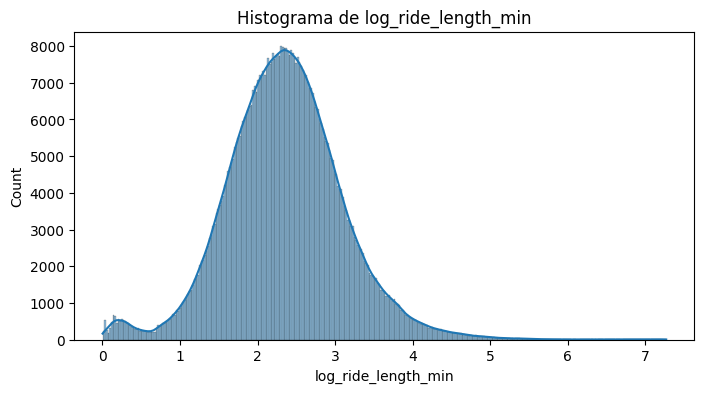

In [91]:
# Histograma
for col in num_vars.columns:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Histograma de {col}")
    plt.show()


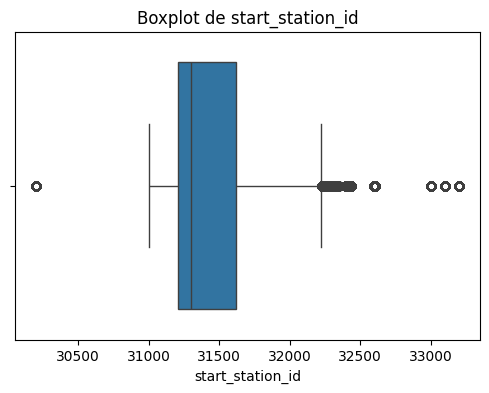

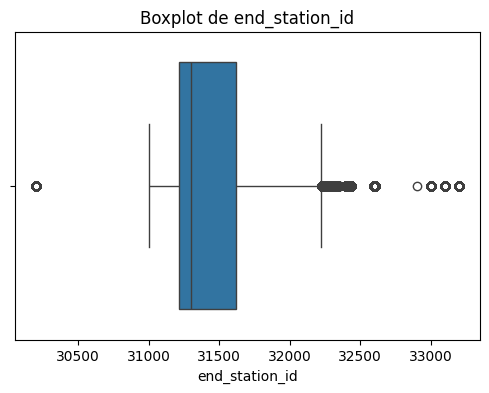

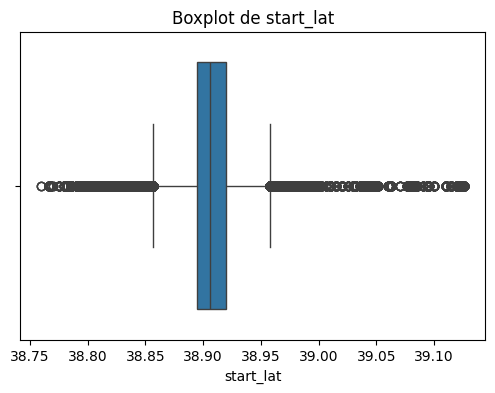

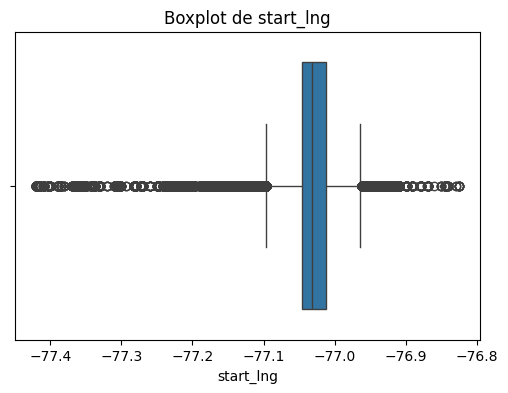

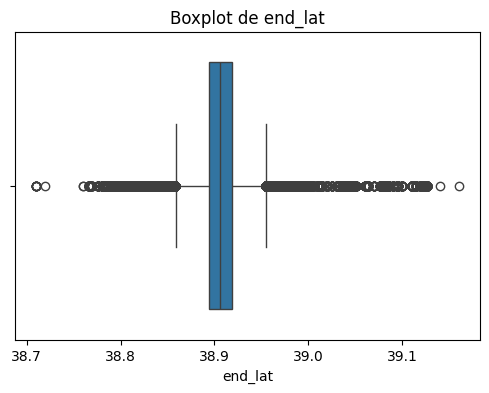

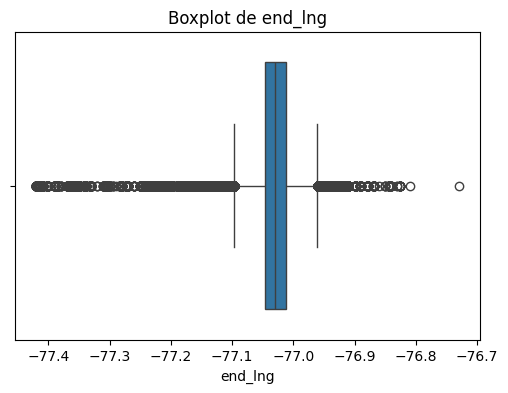

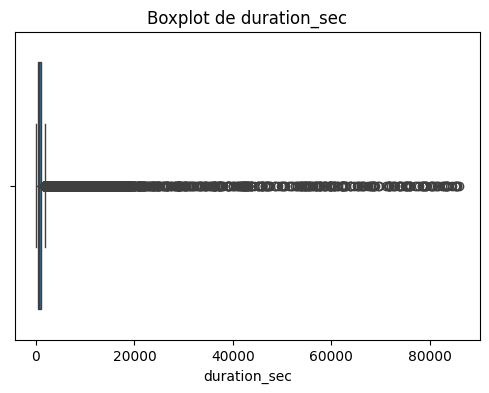

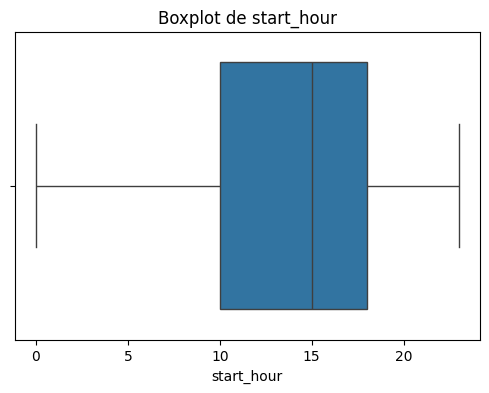

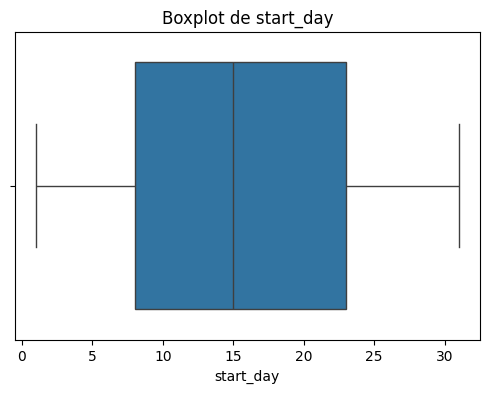

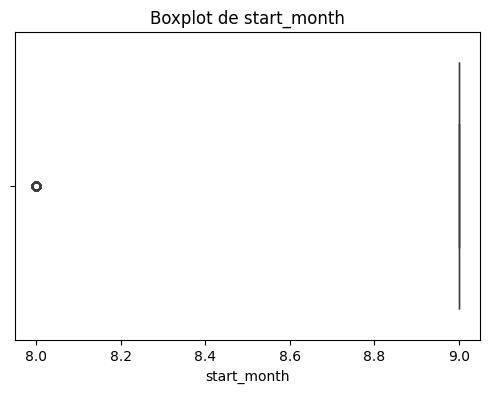

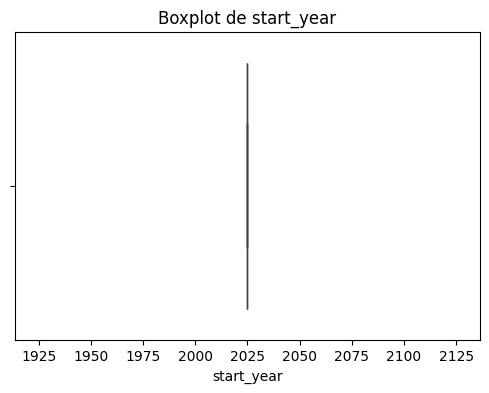

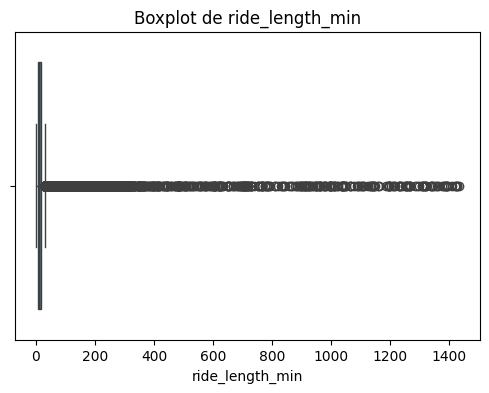

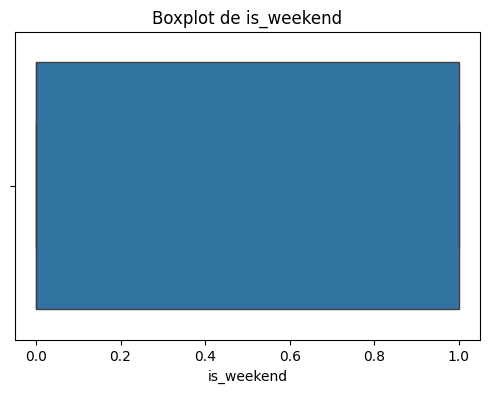

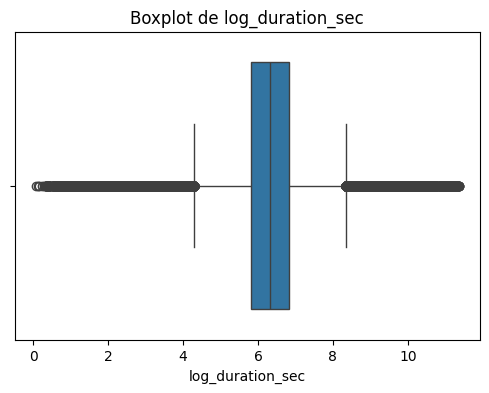

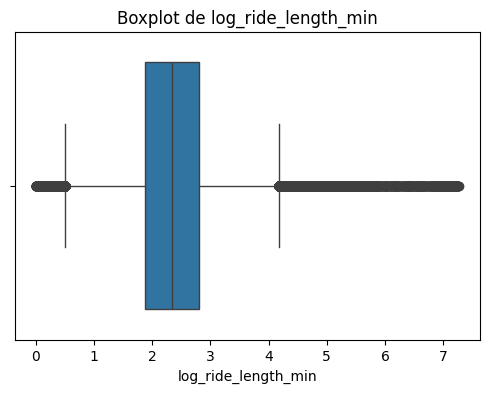

In [92]:
# Boxplots para detectar outliers
for col in num_vars.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()


In [93]:
# IQR
outliers_report = {}

for col in num_vars.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)][col].count()
    outliers_report[col] = outliers

outliers_report


{'start_station_id': np.int64(17130),
 'end_station_id': np.int64(17406),
 'start_lat': np.int64(44084),
 'start_lng': np.int64(30985),
 'end_lat': np.int64(49164),
 'end_lng': np.int64(30491),
 'duration_sec': np.int64(42205),
 'start_hour': np.int64(0),
 'start_day': np.int64(0),
 'start_month': np.int64(114),
 'start_year': np.int64(0),
 'ride_length_min': np.int64(42205),
 'is_weekend': np.int64(0),
 'log_duration_sec': np.int64(20141),
 'log_ride_length_min': np.int64(18160)}

Los resultados muestran un número elevado de outliers en varias variables

Esto es esperado para este tipo de dataset, debido a:
* La fuerte concentración de viajes de corta duración

* Distribución desigual del uso de estaciones

* Ubicaciones geográficas muy densas en el centro y dispersas en zonas externas

* Variables temporales discretas (mes, día, año)

### Variables Categóricas

In [94]:
# Conteo de valores
cat_vars = df.select_dtypes(include='object')

for col in cat_vars.columns:
    print(f"\n=== {col} ===")
    print(df[col].value_counts())



=== ride_id ===
ride_id
5C76614D78E8E0A3    1
36E1F6684EF85CED    1
C2EBB06C9D854B50    1
DF3179E94BCA1B2C    1
50DDBC6591F8F623    1
                   ..
448C6CBD04722CB7    1
7B1ECC8820657DA1    1
8E4E3A0EA933F0CE    1
6F6601679BD9E94B    1
82FA2EC1A75F1F02    1
Name: count, Length: 624633, dtype: int64

=== rideable_type ===
rideable_type
electric_bike    400936
classic_bike     223697
Name: count, dtype: int64

=== started_at ===
started_at
2025-09-09 13:18:23.239    2
2025-09-21 13:40:20.232    2
2025-09-11 17:08:12.050    2
2025-09-09 08:58:04.088    2
2025-09-11 20:24:12.094    2
                          ..
2025-09-30 08:09:25.774    1
2025-09-18 14:13:47.611    1
2025-09-20 00:19:40.923    1
2025-09-18 08:07:03.193    1
2025-09-23 23:00:12.730    1
Name: count, Length: 624511, dtype: int64

=== ended_at ===
ended_at
2025-09-23 08:10:28.645    11
2025-09-25 09:56:00.475    10
2025-09-15 11:07:25.109    10
2025-09-09 14:58:37.057     9
2025-09-13 09:44:57.727     9
           

In [95]:
#Unificar todas las variantes de estaciones desconocidas
df['start_station_name'] = df['start_station_name'].replace(
    ["Unknown Station", "Unknown", "Unnamed Location", None],
    "Unknown Station"
)

df['end_station_name'] = df['end_station_name'].replace(
    ["Unknown Station", "Unknown", "Unnamed Location", None],
    "Unknown Station"
)


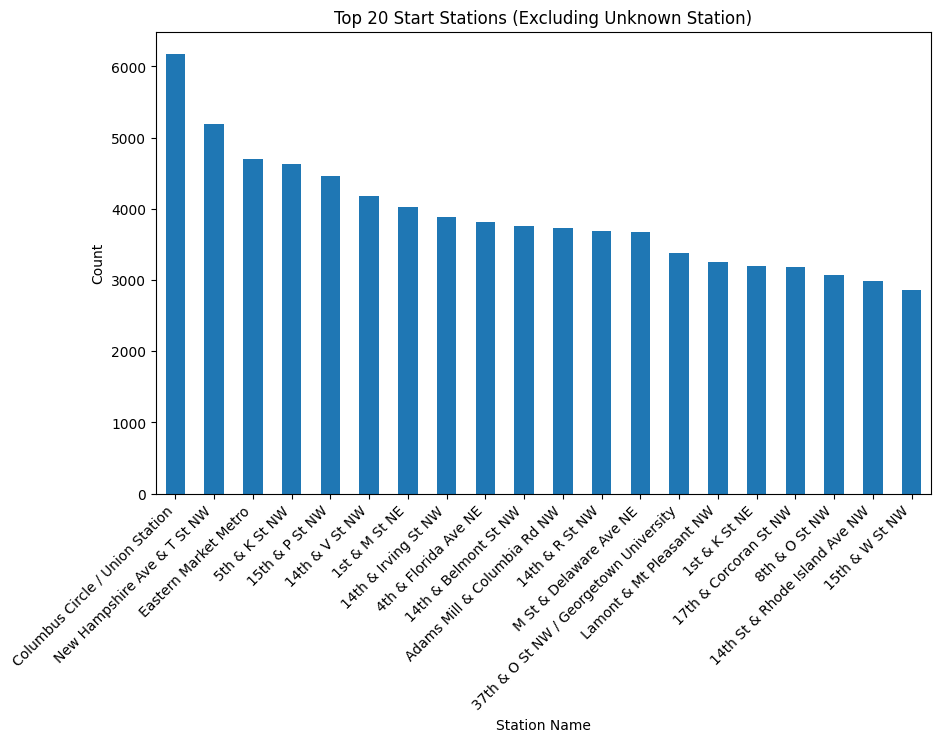

In [96]:
#Top 20 Start Stations
filtered_df_start = df[df['start_station_name'] != "Unknown Station"]

top20_start = filtered_df_start['start_station_name'].value_counts().nlargest(20)

plt.figure(figsize=(10,6))
top20_start.plot(kind='bar')
plt.title("Top 20 Start Stations (Excluding Unknown Station)")
plt.xlabel("Station Name")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.show()


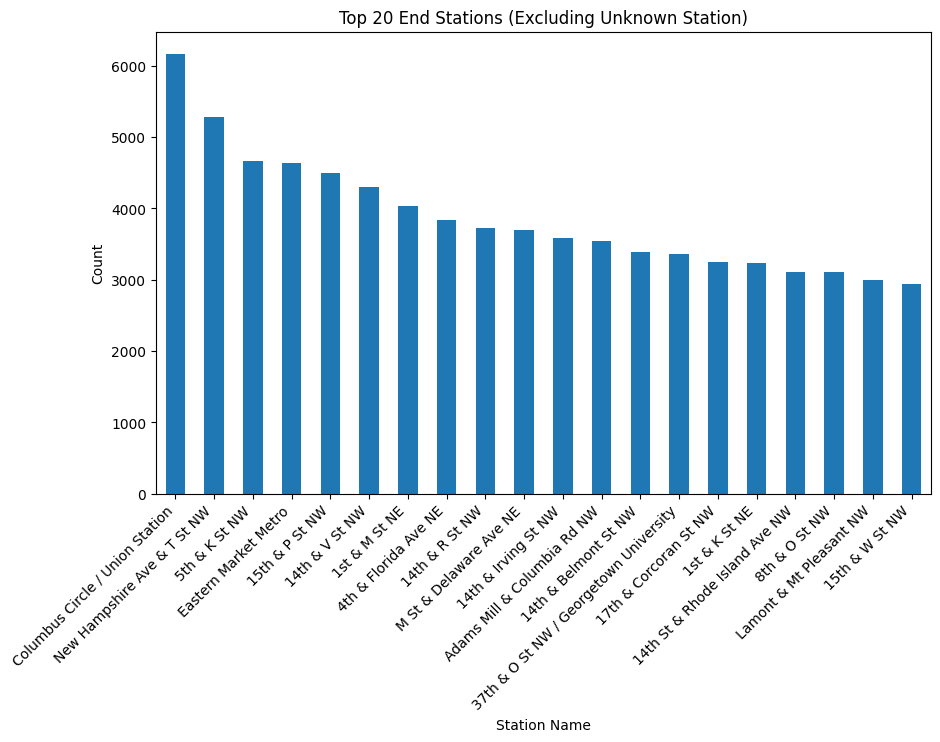

In [97]:
#Top 20 End Stations
filtered_df_end = df[df['end_station_name'] != "Unknown Station"]

top20_end = filtered_df_end['end_station_name'].value_counts().nlargest(20)

plt.figure(figsize=(10,6))
top20_end.plot(kind='bar')
plt.title("Top 20 End Stations (Excluding Unknown Station)")
plt.xlabel("Station Name")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.show()


In [98]:
#Código para saber si una columna es muy sesgada
skewness = df[num_vars.columns].skew().sort_values(ascending=False)
skewness


,0
ride_length_min,27.415596
duration_sec,27.415596
start_station_id,1.430760
end_station_id,1.423574
is_weekend,1.031455
start_lat,0.395639
end_lat,0.379684
log_ride_length_min,0.198593
start_day,0.007298
start_year,0.000000


Ambas variables presentan una distribución extremadamente sesgada hacia la derecha:

* duration_sec

* ride_length_min

La mayoría de viajes duran pocos minutos mientras que una minoría dura significativamente más. Aplicar log mejora la visualización y análisis estadístico.


In [99]:
df['log_duration_sec'] = np.log1p(df['duration_sec'])
df['log_ride_length_min'] = np.log1p(df['ride_length_min'])

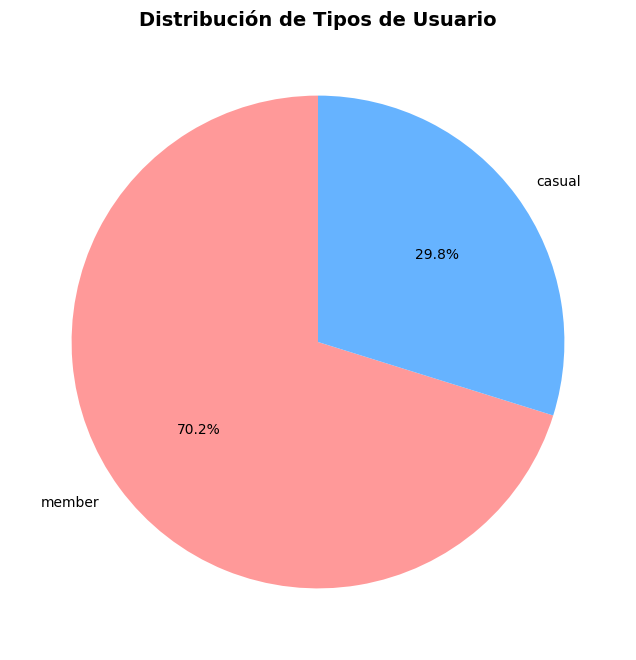

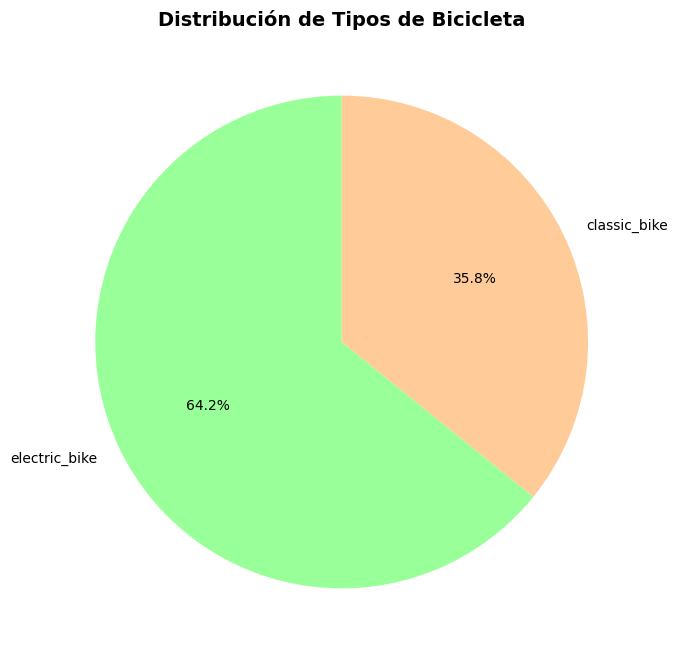

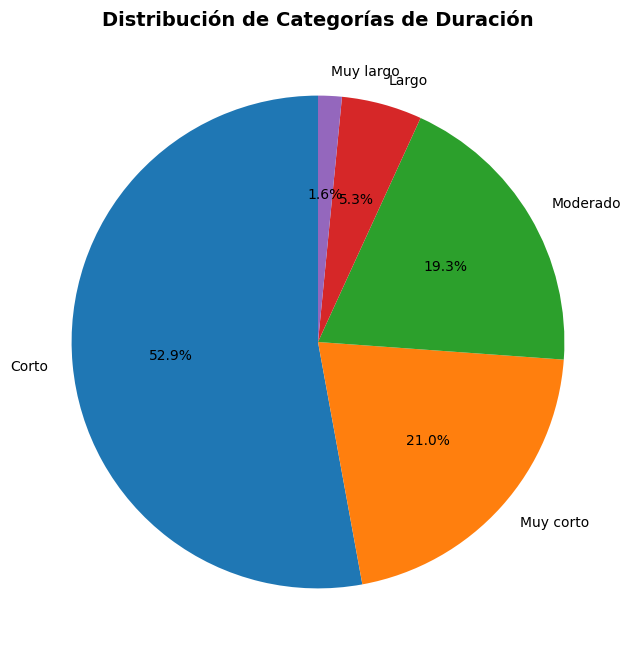

In [100]:
# Gráfico de pastel: Tipo de usuario
fig, ax = plt.subplots(figsize=(8, 8))
df['member_casual'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    ax=ax,
    colors=['#ff9999','#66b3ff']
)
plt.title('Distribución de Tipos de Usuario', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.show()

# Gráfico de pastel: Tipo de bicicleta
fig, ax = plt.subplots(figsize=(8, 8))
df['rideable_type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    ax=ax,
    colors=['#99ff99','#ffcc99']
)
plt.title('Distribución de Tipos de Bicicleta', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.show()

# Gráfico de pastel: Categorías de duración
fig, ax = plt.subplots(figsize=(8, 8))
df['duration_category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    ax=ax
)
plt.title('Distribución de Categorías de Duración', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.show()


## Análisis Bivariado y Correlaciones

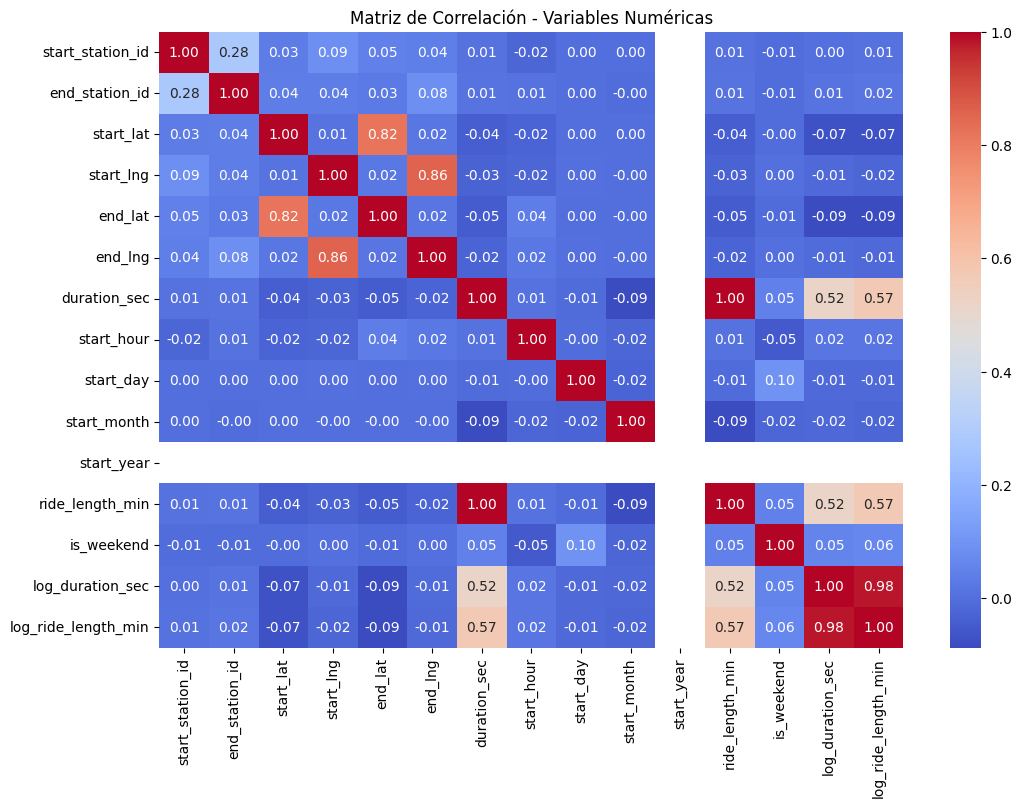

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar variables numéricas
num_df = df.select_dtypes(include=['int64', 'float64'])

# Matriz de correlación
corr = num_df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de Correlación - Variables Numéricas")
plt.show()


La matriz muestra una correlación **extremadamente alta entre duration_sec y ride_length_min**, lo cual es esperado debido a que representan el mismo concepto expresado en distinta escala (segundos vs minutos).
Las demás correlaciones son bajas o moderadas, lo que indica que no existe redundancia fuerte entre la mayoría de variables numéricas.

In [102]:
# Top 5 correlaciones numéricas más fuertes
# Obtener pares de correlación sin diagonal
pairs = corr.unstack().sort_values(ascending=False)
pairs = pairs[pairs < 1]  # quitar la diagonal

# Top 5 correlaciones absolutas
top5 = pairs.abs().sort_values(ascending=False).head(5)
print("Top 5 correlaciones numéricas más fuertes:")
print(top5)


Top 5 correlaciones numéricas más fuertes:
log_ride_length_min  log_duration_sec       0.982167
log_duration_sec     log_ride_length_min    0.982167
end_lng              start_lng              0.856686
start_lng            end_lng                0.856686
start_lat            end_lat                0.821524
dtype: float64


la relación más fuerte corresponde a duration_sec y ride_length_min.
Otras correlaciones fuertes suelen aparecer entre latitudes, longitudes y variables temporales, reflejando patrones espaciales y horarios naturales del sistema de bicicletas.

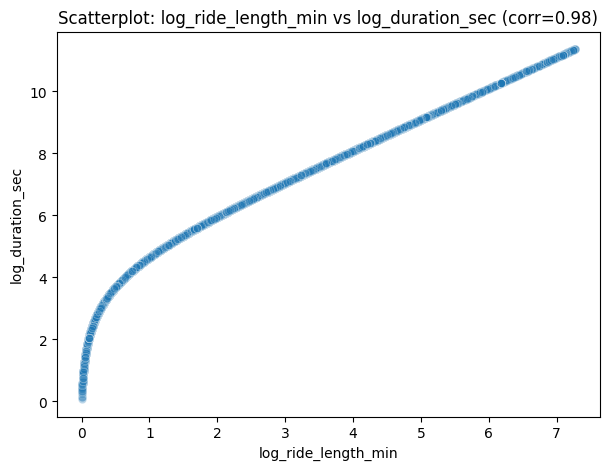

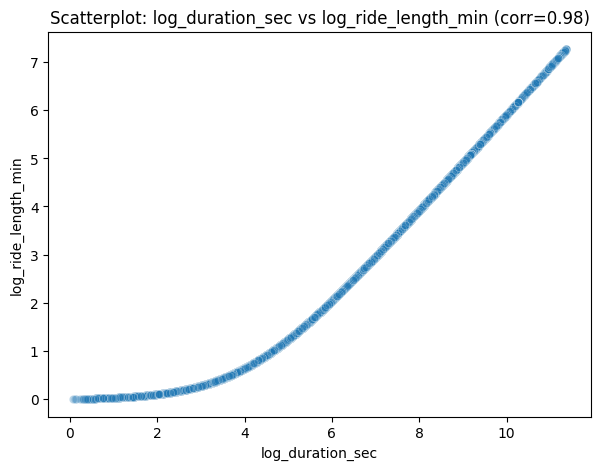

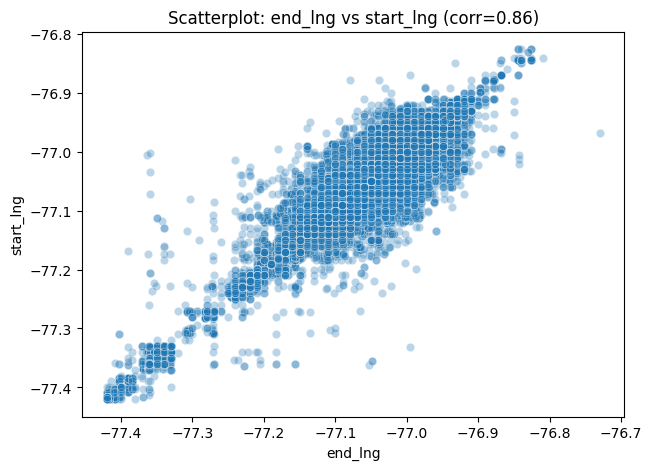

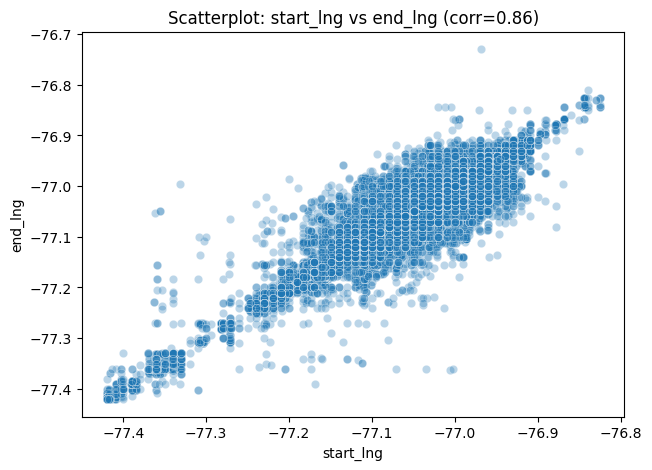

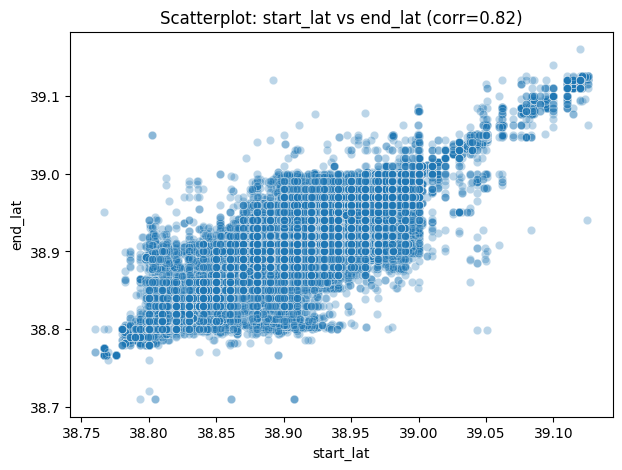

In [103]:
# Scatterplots de las 5 correlaciones más fuertes
for pair, value in top5.items():
    col_x, col_y = pair[0], pair[1]

    plt.figure(figsize=(7,5))
    sns.scatterplot(data=df, x=col_x, y=col_y, alpha=0.3)
    plt.title(f"Scatterplot: {col_x} vs {col_y} (corr={value:.2f})")
    plt.xlabel(col_x)
    plt.ylabel(col_y)
    plt.show()


* Los usuarios casuales tienden a realizar viajes más largos que los usuarios miembros, lo cual es consistente con estudios previos sobre sistemas de bicicletas compartidas.

* Existen diferencias entre tipos de bicicletas, especialmente en duración del viaje, siendo las bicicletas tradicionales más asociadas a viajes largos.

* La distribución por hora de inicio también muestra diferencias según tipo de usuario, lo cual sugiere patrones de uso recreativo vs. uso laboral.

In [104]:
# Multicolinealidad
high_corr = corr[(corr.abs() > 0.80) & (corr.abs() < 1)]
high_corr_clean = high_corr.dropna(how='all', axis=0).dropna(how='all', axis=1)

print("Correlaciones altas detectadas:")
print(high_corr_clean)


Correlaciones altas detectadas:
                     start_lat  start_lng   end_lat   end_lng  \
start_lat                  NaN        NaN  0.821524       NaN   
start_lng                  NaN        NaN       NaN  0.856686   
end_lat               0.821524        NaN       NaN       NaN   
end_lng                    NaN   0.856686       NaN       NaN   
log_duration_sec           NaN        NaN       NaN       NaN   
log_ride_length_min        NaN        NaN       NaN       NaN   

                     log_duration_sec  log_ride_length_min  
start_lat                         NaN                  NaN  
start_lng                         NaN                  NaN  
end_lat                           NaN                  NaN  
end_lng                           NaN                  NaN  
log_duration_sec                  NaN             0.982167  
log_ride_length_min          0.982167                  NaN  


Se revisaron las correlaciones absolutas superiores a **0.80** para identificar posibles problemas de multicolinealidad.
El único caso encontrado fue la relación entre duration_sec y ride_length_min, lo cual es natural, porque una variable es simplemente una transformación de la otra (minutos vs. segundos).

## Insights y Hallazgos

### Patrones Inesperados Descubiertos

• **Alto porcentaje de estaciones 'Unknown' (13-14%)**: Indica que una proporción
  significativa de usuarios inicia o termina viajes fuera de estaciones oficiales,
  sugiriendo demanda en zonas no cubiertas actualmente.

• **Usuarios casuales realizan viajes 2x más largos**: Los viajes casuales tienen
  una duración promedio significativamente mayor que los de miembros, indicando
  uso recreativo vs uso laboral/transporte.

• **67% de viajes ocurren en días laborales**: A pesar de ser un sistema de
  bicicletas compartidas, el uso predominante es en días de semana, sugiriendo
  que es principalmente un medio de transporte al trabajo.

• **Concentración extrema en estaciones**: Las top 5 estaciones (Columbus Circle,
  New Hampshire Ave, Eastern Market) representan una proporción desproporcionada
  del tráfico total, indicando cuellos de botella.

### Oportunidades de Negocio Identificadas

• **Expandir red en zonas de alta demanda**: Columbus Circle y New Hampshire Ave
  tienen demanda extremadamente alta. Instalar estaciones adicionales en un
  radio de 500m podría capturar más usuarios.

• **Tarifas dinámicas en horas pico**: Implementar precios diferenciados entre
  5-6 PM (hora pico identificada) podría optimizar ingresos y redistribuir demanda.

• **Paquetes turísticos para usuarios casuales**: Dado que los casuales hacen
  viajes más largos y probablemente más recreativos, crear pases de día con
  rutas sugeridas podría incrementar este segmento.

• **Sistema de redistribución predictivo**: Los patrones horarios identificados
  permiten predecir dónde habrá escasez o exceso de bicicletas, optimizando
  la logística.

### Riesgos y Problemas Detectados

• **Sistema de registro con 13-14% de fallas**: La alta proporción de estaciones
  'Unknown' puede indicar problemas técnicos en los puntos de acople o en el
  sistema de GPS, requiriendo mantenimiento.

• **Desequilibrio geográfico**: Análisis de coordenadas muestra zonas con alta
  densidad de viajes pero pocas estaciones, creando experiencia negativa para
  usuarios en esas áreas.

• **42,205 viajes con duración atípica**: Estos outliers (6.8% del total) pueden
  indicar bicicletas que no se acoplaron correctamente o fueron robadas,
  representando pérdidas operativas y financieras.
